In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [138]:
# =====================================================
# Load Dataset & Basic Preprocessing
# =====================================================
df = pd.read_csv('../Data/TCS_stock_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df = df.sort_index()

In [139]:
df["Daily_Return"] = df["Close"].pct_change() * 100
df["Absolute_difference"] = df["Close"] - df["Open"] 
df["Daily_Range"] = df["High"] - df["Low"] 
print(df.shape)

(3850, 8)


In [140]:
df.head()

,Open,High,Low,Close,Volume,Daily_Return,Absolute_difference,Daily_Range
Date,,,,,,,,
2010-01-01,421.25,421.25,418.03,420.00,4608027,NaN,-1.25,3.22
2010-01-04,418.24,434.01,418.24,430.67,16619599,2.540476,12.43,15.77
2010-01-05,430.84,442.45,430.84,438.77,9933699,1.880790,7.93,11.61
2010-01-06,437.92,438.20,437.24,437.73,2560889,-0.237026,-0.19,0.96
2010-01-07,438.48,441.55,430.75,436.70,2281757,-0.235305,-1.78,10.80


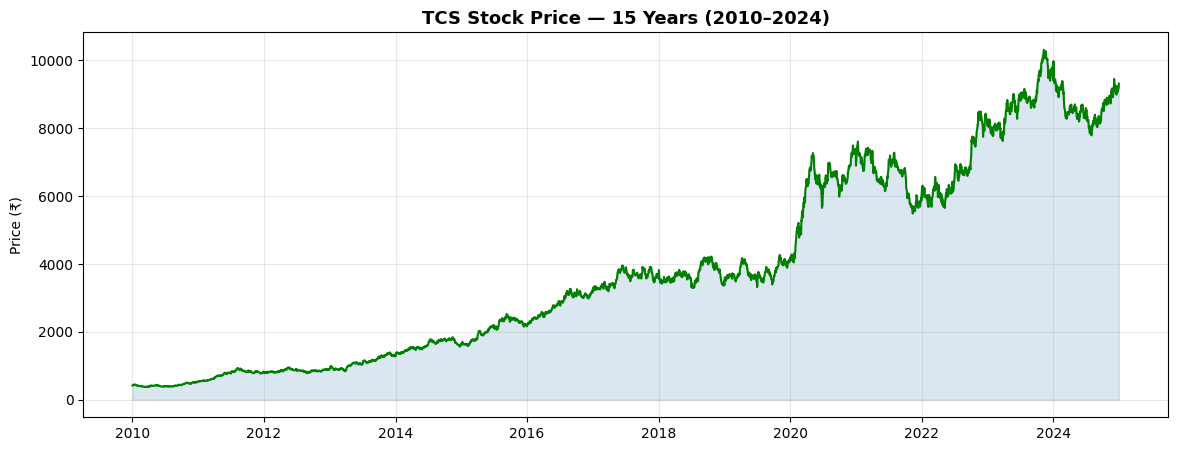

Slope: 2.4389


In [141]:
# Close Trend:
x = np.arange(len(df))
y = df['Close'].values
coeffs = np.polyfit(x, y, deg=1)

plt.figure(figsize=(14,5))
plt.plot(df.index, df['Close'], color='green')
plt.fill_between(df.index, df['Close'], alpha=0.2, color='steelblue')
plt.title('TCS Stock Price — 15 Years (2010–2024)', fontsize=13, fontweight='bold')
plt.ylabel('Price (₹)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Slope: {coeffs[0]:.4f}")

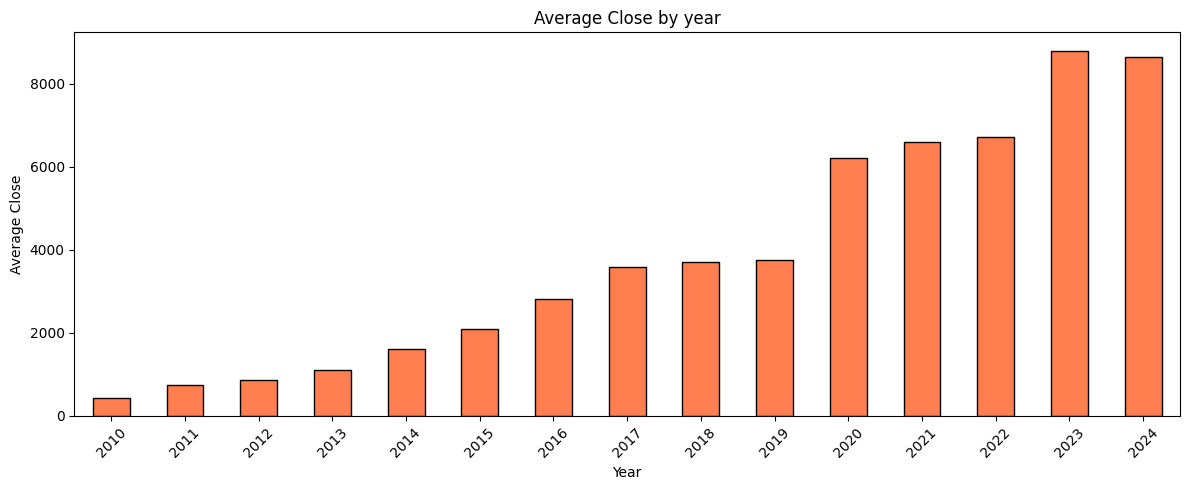

year
2010     430.034574
2011     749.656406
2012     854.281556
2013    1100.773891
2014    1603.773867
2015    2086.349023
2016    2807.188911
2017    3578.739216
2018    3709.070428
2019    3763.119066
2020    6211.809419
2021    6608.781318
2022    6721.132695
2023    8799.116510
2024    8649.814825
Name: Close, dtype: float64


In [142]:
df['year'] = df.index.year

yearly = df.groupby('year')['Close'].mean()

plt.figure(figsize=(12,5))
yearly.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Close by year')
plt.xlabel('Year')
plt.ylabel('Average Close')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(yearly)
df.drop("year", axis=1, inplace=True)

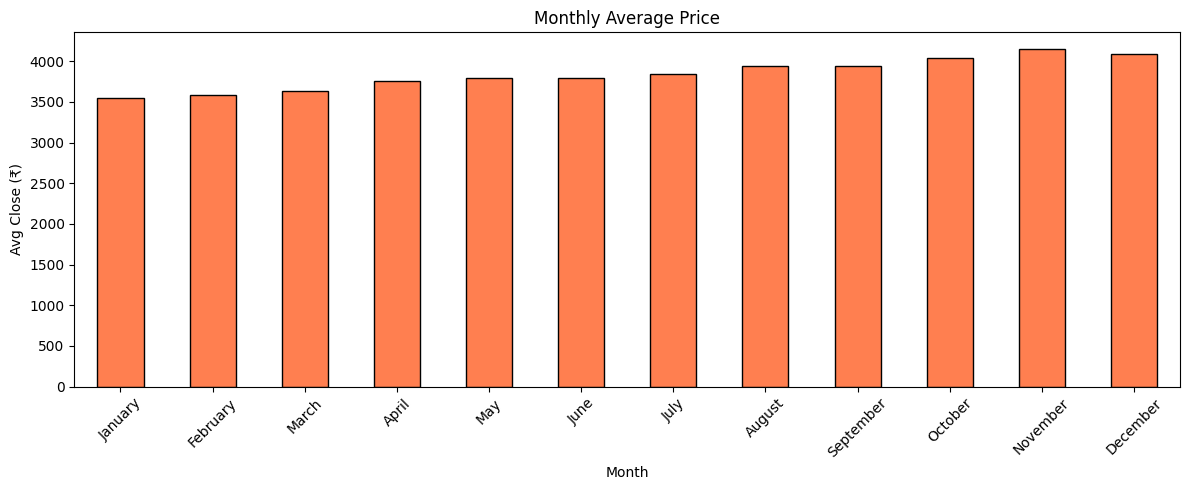

month
January      3553.655719
February     3585.921485
March        3637.593870
April        3756.918318
May          3790.761652
June         3789.372430
July         3848.833746
August       3944.292693
September    3936.152586
October      4039.804393
November     4148.462853
December     4092.077850
Name: Close, dtype: float64


In [143]:
df['month'] = df.index.month_name()

month_order = ['January','February','March','April',
               'May','June','July','August',
               'September','October','November','December']

month_avg = df.groupby('month')['Close'].mean()
month_avg = month_avg.reindex(month_order)

plt.figure(figsize=(12,5))
month_avg.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Monthly Average Price')
plt.xlabel('Month')
plt.ylabel('Avg Close (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(month_avg)
df.drop("month", axis=1, inplace=True)

In [144]:
# ===== BEST & WORST DAYS =====
print("TOP 5 BEST DAYS:")
print(df['Daily_Return'].nlargest(5))

print("\nTOP 5 WORST DAYS:")
print(df['Daily_Return'].nsmallest(5))

TOP 5 BEST DAYS:
Date
2020-10-19    5.084178
2019-07-05    5.028823
2022-01-05    4.874252
2020-03-19    4.767712
2020-02-03    4.730666
Name: Daily_Return, dtype: float64

TOP 5 WORST DAYS:
Date
2020-02-20   -5.450187
2021-01-01   -5.419344
2018-10-04   -5.009675
2022-01-04   -4.802742
2020-06-26   -4.244043
Name: Daily_Return, dtype: float64


In [145]:
print("\nDaily Return Stats:")
print(df['Daily_Return'].describe().round(3))


Daily Return Stats:
count    3849.000
mean        0.089
std         1.329
min        -5.450
25%        -0.761
50%         0.088
75%         0.913
max         5.084
Name: Daily_Return, dtype: float64


In [146]:
print("VOLUME STATS:")
print(f"Average Daily Volume : {df['Volume'].mean():,.0f}")
print(f"Max Volume           : {df['Volume'].max():,.0f}")
print(f"Min Volume           : {df['Volume'].min():,.0f}")

VOLUME STATS:
Average Daily Volume : 4,321,025
Max Volume           : 19,458,655
Min Volume           : 1,805,769


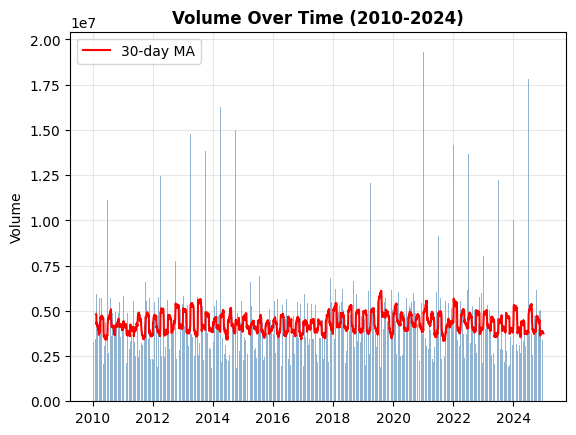

In [147]:
plt.bar(df.index, df['Volume'], 
            color='steelblue', alpha=0.6, width=1)
plt.plot(df['Volume'].rolling(30).mean(), 
             color='red', linewidth=1.5, label='30-day MA')
plt.title('Volume Over Time (2010-2024)', fontweight='bold')
plt.ylabel('Volume')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

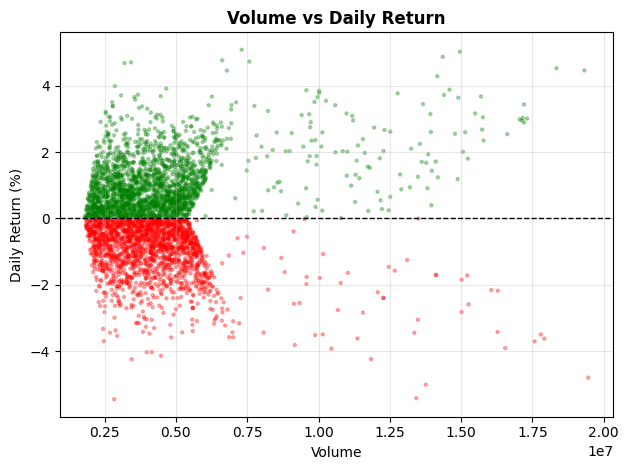

In [148]:
scatter_colors = ['green' if x > 0 else 'red' for x in df['Daily_Return']]
plt.scatter(df['Volume'], df['Daily_Return'],
                c=scatter_colors, alpha=0.3, s=5)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Volume vs Daily Return', fontweight='bold')
plt.xlabel('Volume')
plt.ylabel('Daily Return (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [149]:
top10_volume = df.nlargest(10, 'Volume')[['Close', 'Volume', 'Daily_Return']]
print("📊 TOP 10 HIGH VOLUME DAYS:")
print(top10_volume)

📊 TOP 10 HIGH VOLUME DAYS:
              Close    Volume  Daily_Return
Date                                       
2022-01-04  5948.81  19458655     -4.802742
2021-01-04  7207.05  19323449      4.460749
2022-10-05  7659.17  18345200      4.526231
2016-07-01  2798.90  17919904     -3.622797
2024-07-02  8294.79  17796126     -3.499244
2021-04-05  7062.99  17576240     -3.706547
2013-07-05  1145.34  17314416      3.012097
2013-07-04  1111.85  17209327      2.893816
2019-07-04  3476.36  17205249      3.435082
2020-01-01  4195.77  17164579      3.028912


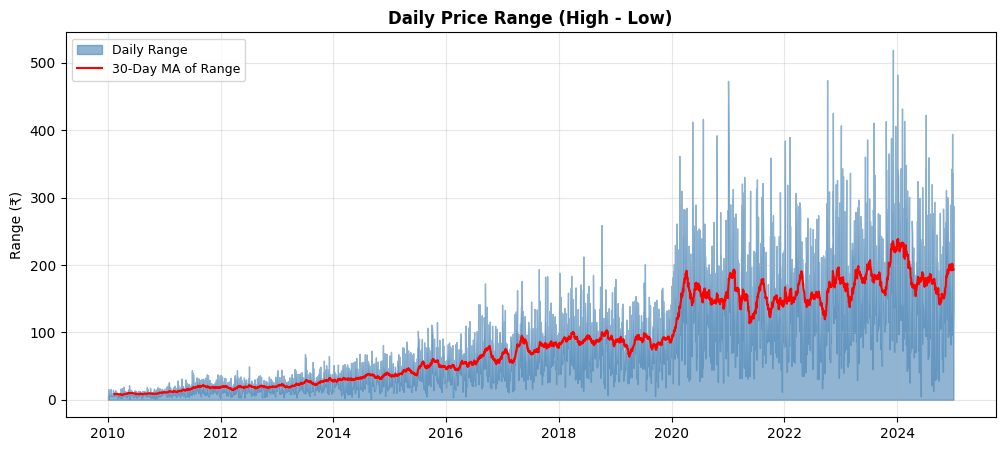

In [151]:
plt.figure(figsize=(12,5))
plt.fill_between(df.index, df['Daily_Range'], 
                 alpha=0.6, color='steelblue', label='Daily Range')
plt.plot(df['Daily_Range'].rolling(30).mean(), 
         color='red', linewidth=1.5, label='30-Day MA of Range')

plt.title('Daily Price Range (High - Low)', fontweight='bold')
plt.ylabel('Range (₹)')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

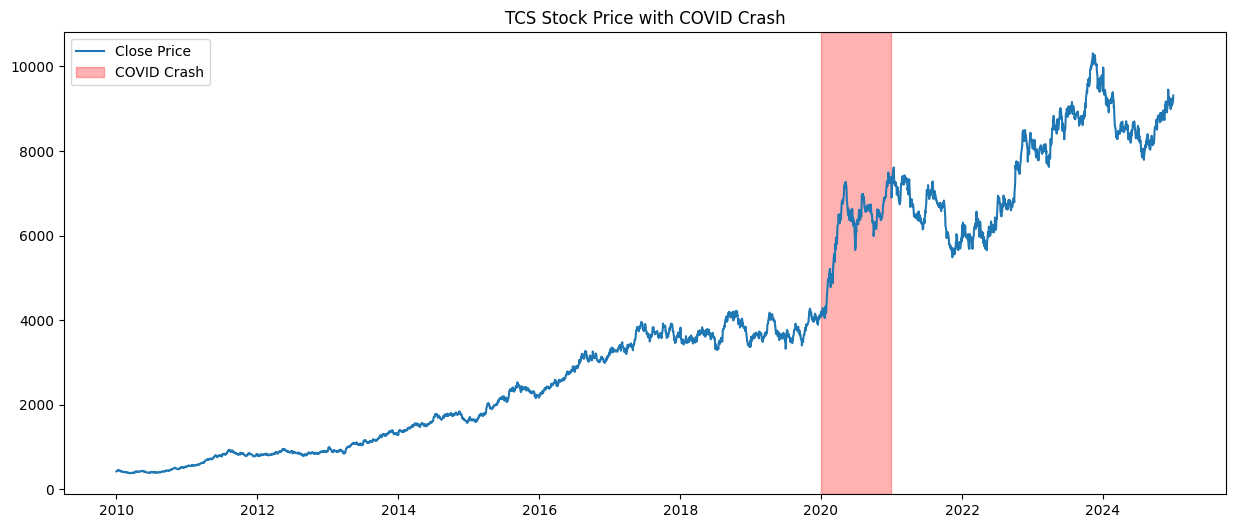

In [153]:
plt.figure(figsize=(15,6))
plt.plot(df.index,df["Close"],label="Close Price")
plt.axvspan('2020-01-01','2020-12-31',color="red",alpha=0.3,label="COVID Crash")

plt.legend()
plt.title("TCS Stock Price with COVID Crash")
plt.show()